In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/raw/Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
df.info()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


0

In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [5]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ","_")
)

In [8]:
df.to_csv(
    "data/processed/telco_cleaned.csv",
    index=False
)

In [9]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


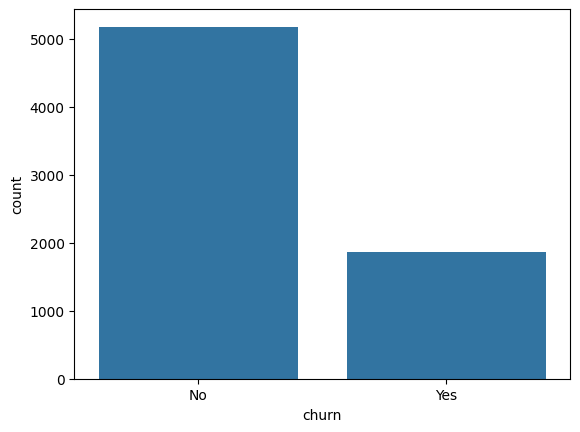

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="churn"
)

plt.show()

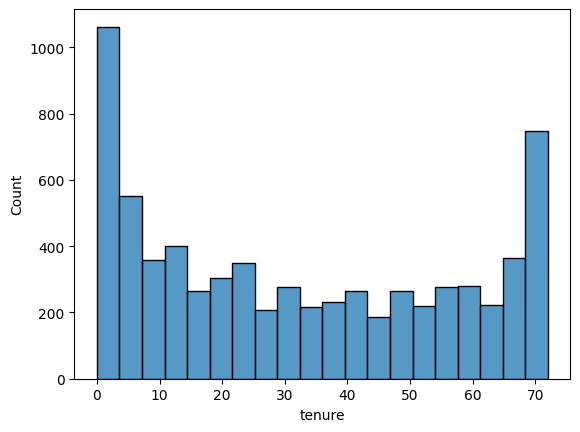

In [11]:
sns.histplot(
    df["tenure"],
    bins=20
)

plt.show()

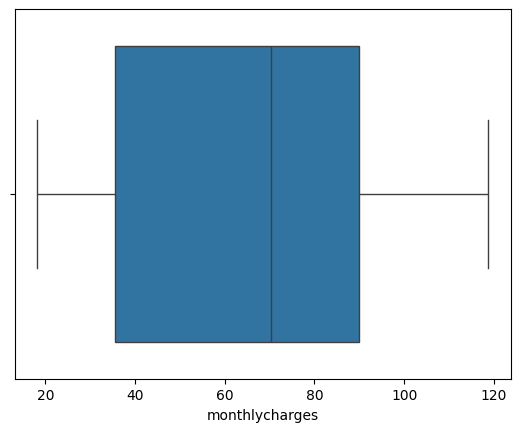

In [12]:
sns.boxplot(
    x=df["monthlycharges"]
)

plt.show()

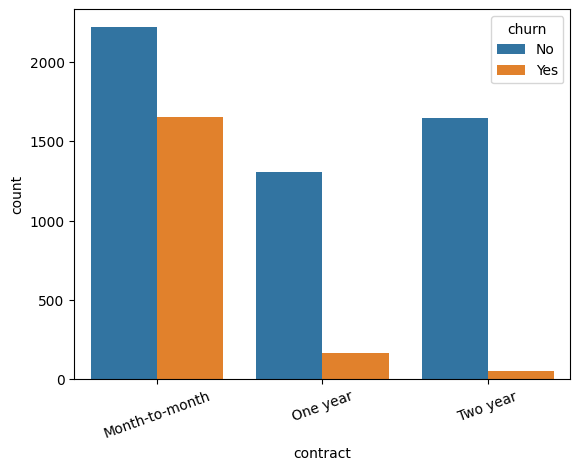

In [13]:
sns.countplot(
    data=df,
    x="contract",
    hue="churn"
)

plt.xticks(rotation=20)
plt.show()

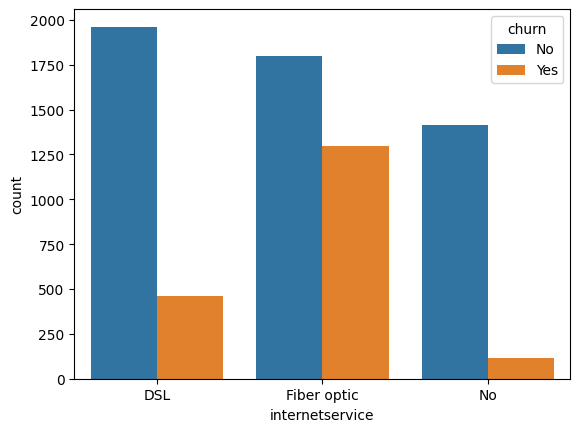

In [14]:
sns.countplot(
    data=df,
    x="internetservice",
    hue="churn"
)

plt.show()

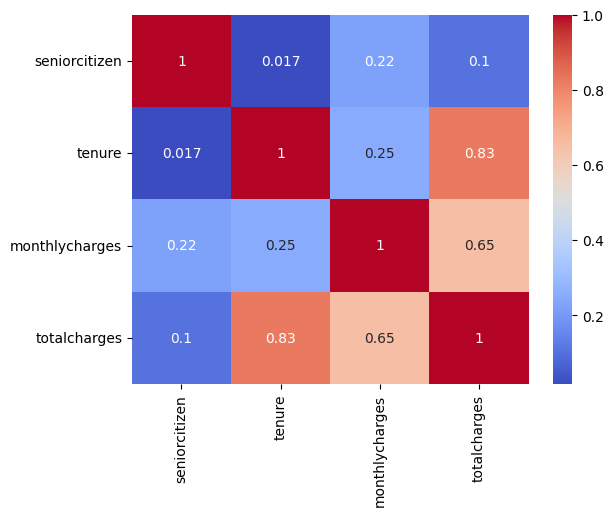

In [15]:
numeric_df = df.select_dtypes(
    include=np.number
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()